# ISLES 2022 — Exploratory Data Analysis

**Dataset:** ISLES 2022 (Ischemic Stroke Lesion Segmentation Challenge 2022)  
**Source:** [Zenodo](https://zenodo.org/record/7153326)  
**Модальности:** DWI (b=1000), ADC, FLAIR  
**Задача:** Сегментация очага острого ишемического инсульта

---

## Цели EDA

1. Понять структуру датасета
2. Распределение размеров очагов
3. Проверить spacing/размеры volumes
4. Визуализация примеров
5. Проблемные кейсы (posterior fossa, мелкие, мультифокальные)
6. Определить стратегию splits

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from tqdm.auto import tqdm

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Project root: {project_root}")

Project root: c:\Users\mfayz\MRI Stroke Assistance


## 1. Структура датасета

In [2]:
data_root = project_root / "data" / "raw" / "isles22" / "ISLES-2022"
derivatives_root = project_root / "data" / "raw" / "isles22" / "derivatives"

# Найти все кейсы
subjects = sorted([d.name for d in data_root.glob("sub-*") if d.is_dir()])
print(f"Всего кейсов: {len(subjects)}")
print(f"Пример ID: {subjects[0]}")

Всего кейсов: 250
Пример ID: sub-strokecase0001


In [3]:
# Проверить структуру одного кейса
example_sub = subjects[0]
example_path = data_root / example_sub / "ses-0001"

print(f"Структура {example_sub}:")
print(f"  DWI: {list(example_path.glob('dwi/*dwi.nii.gz'))}")
print(f"  ADC: {list(example_path.glob('dwi/*adc.nii.gz'))}")
print(f"  FLAIR: {list(example_path.glob('anat/*FLAIR.nii.gz'))}")
print(f"  Mask: {list((derivatives_root / example_sub / 'ses-0001').glob('*msk.nii.gz'))}")

Структура sub-strokecase0001:
  DWI: [WindowsPath('c:/Users/mfayz/MRI Stroke Assistance/data/raw/isles22/ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_dwi.nii.gz')]
  ADC: [WindowsPath('c:/Users/mfayz/MRI Stroke Assistance/data/raw/isles22/ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_adc.nii.gz')]
  FLAIR: [WindowsPath('c:/Users/mfayz/MRI Stroke Assistance/data/raw/isles22/ISLES-2022/sub-strokecase0001/ses-0001/anat/sub-strokecase0001_ses-0001_FLAIR.nii.gz')]
  Mask: [WindowsPath('c:/Users/mfayz/MRI Stroke Assistance/data/raw/isles22/derivatives/sub-strokecase0001/ses-0001/sub-strokecase0001_ses-0001_msk.nii.gz')]


## 2. Загрузка данных — Helper функции

In [4]:
def load_subject_paths(subject_id: str) -> dict:
    """Получить пути ко всем файлам одного кейса."""
    sub_path = data_root / subject_id / "ses-0001"
    deriv_path = derivatives_root / subject_id / "ses-0001"
    
    dwi = list(sub_path.glob("dwi/*dwi.nii.gz"))[0]
    adc = list(sub_path.glob("dwi/*adc.nii.gz"))[0]
    flair = list(sub_path.glob("anat/*FLAIR.nii.gz"))[0]
    mask = list(deriv_path.glob("*msk.nii.gz"))[0]
    
    return {
        "subject_id": subject_id,
        "dwi": dwi,
        "adc": adc,
        "flair": flair,
        "mask": mask,
    }


def compute_lesion_stats(mask_path: Path) -> dict:
    """Вычислить объём очага и другие метрики."""
    img = nib.load(mask_path)
    mask = img.get_fdata()
    spacing = img.header.get_zooms()[:3]
    
    voxel_volume_mm3 = np.prod(spacing)
    lesion_voxels = (mask > 0).sum()
    lesion_volume_ml = (lesion_voxels * voxel_volume_mm3) / 1000  # mm³ → ml
    
    return {
        "spacing": spacing,
        "shape": mask.shape,
        "lesion_voxels": int(lesion_voxels),
        "lesion_volume_ml": float(lesion_volume_ml),
    }


# Тест
paths = load_subject_paths(subjects[0])
stats = compute_lesion_stats(paths["mask"])
print(f"Пример stats: {stats}")

Пример stats: {'spacing': (np.float32(2.0), np.float32(2.0), np.float32(2.0)), 'shape': (112, 112, 73), 'lesion_voxels': 835, 'lesion_volume_ml': 6.68}


## 3. Сбор метаданных по всем кейсам

In [5]:
# Собрать статистику по всем кейсам
metadata = []

for subject_id in tqdm(subjects, desc="Обработка кейсов"):
    try:
        paths = load_subject_paths(subject_id)
        stats = compute_lesion_stats(paths["mask"])
        
        metadata.append({
            "subject_id": subject_id,
            "volume_ml": stats["lesion_volume_ml"],
            "voxels": stats["lesion_voxels"],
            "shape_x": stats["shape"][0],
            "shape_y": stats["shape"][1],
            "shape_z": stats["shape"][2],
            "spacing_x": stats["spacing"][0],
            "spacing_y": stats["spacing"][1],
            "spacing_z": stats["spacing"][2],
        })
    except Exception as e:
        print(f"Ошибка в {subject_id}: {e}")

df = pd.DataFrame(metadata)
print(f"Собрано метаданных: {len(df)} кейсов")
df.head()

Обработка кейсов:   0%|          | 0/250 [00:00<?, ?it/s]

Собрано метаданных: 250 кейсов


,subject_id,volume_ml,voxels,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z
0,sub-strokecase0001,6.680,835,112,112,73,2.0,2.0,2.0
1,sub-strokecase0002,0.944,118,112,112,72,2.0,2.0,2.0
2,sub-strokecase0003,30.984,3873,112,112,72,2.0,2.0,2.0
3,sub-strokecase0004,2.248,281,112,112,72,2.0,2.0,2.0
4,sub-strokecase0005,5.824,728,112,112,72,2.0,2.0,2.0


In [6]:
# Сводная статистика
df.describe()

,volume_ml,voxels,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z
count,250.000000,250.000000,250.00000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,23.423520,2900.556000,122.87600,122.87600,62.736000,1.886135,1.886135,2.604000
std,46.998367,5985.166309,26.19445,26.19445,18.613871,0.266519,0.266519,1.153371
min,0.000000,0.000000,112.00000,112.00000,25.000000,0.875000,0.875000,2.000000
25%,1.576824,197.250000,112.00000,112.00000,72.000000,2.000000,2.000000,2.000000
50%,6.656582,773.500000,112.00000,112.00000,72.000000,2.000000,2.000000,2.000000
75%,21.170277,2696.750000,112.00000,112.00000,73.000000,2.000000,2.000000,2.000000
max,482.152000,60269.000000,256.00000,256.00000,76.000000,2.000000,2.000000,5.000000


## 4. Распределение объёмов очагов

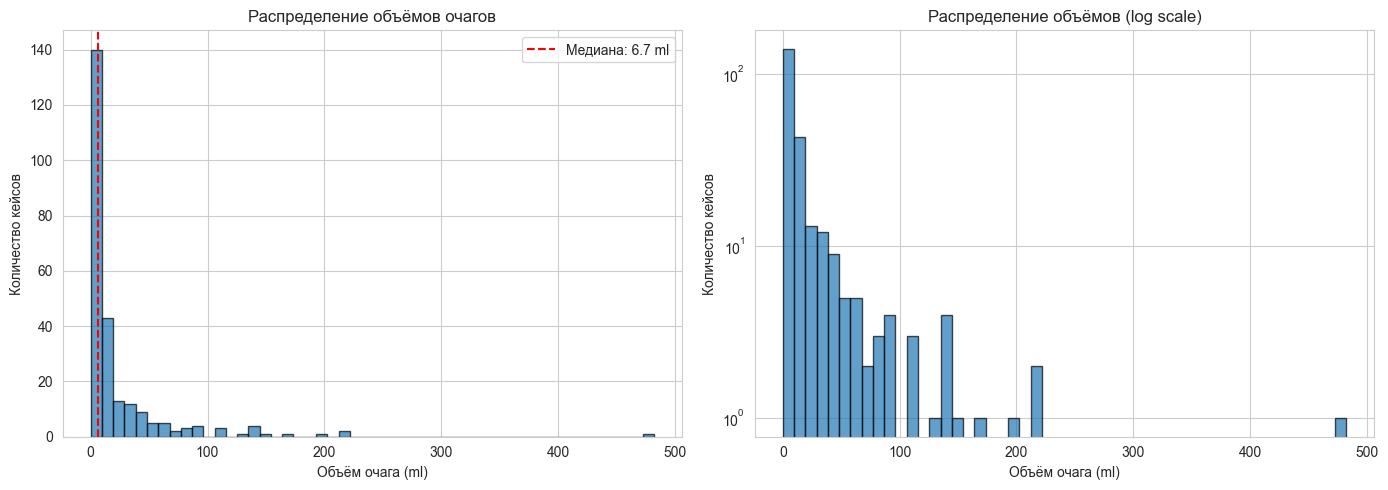

Медиана: 6.66 ml
Среднее: 23.42 ml
Min: 0.00 ml, Max: 482.15 ml


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(df["volume_ml"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Объём очага (ml)")
axes[0].set_ylabel("Количество кейсов")
axes[0].set_title("Распределение объёмов очагов")
axes[0].axvline(df["volume_ml"].median(), color="red", linestyle="--", label=f"Медиана: {df['volume_ml'].median():.1f} ml")
axes[0].legend()

# Log scale
axes[1].hist(df["volume_ml"], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Объём очага (ml)")
axes[1].set_ylabel("Количество кейсов")
axes[1].set_title("Распределение объёмов (log scale)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Медиана: {df['volume_ml'].median():.2f} ml")
print(f"Среднее: {df['volume_ml'].mean():.2f} ml")
print(f"Min: {df['volume_ml'].min():.2f} ml, Max: {df['volume_ml'].max():.2f} ml")

## 5. Стратификация по размеру

Распределение по категориям размера:
size_category
tiny (<1ml)         43
small (1-10ml)      95
medium (10-50ml)    79
large (>50ml)       30
Name: count, dtype: int64


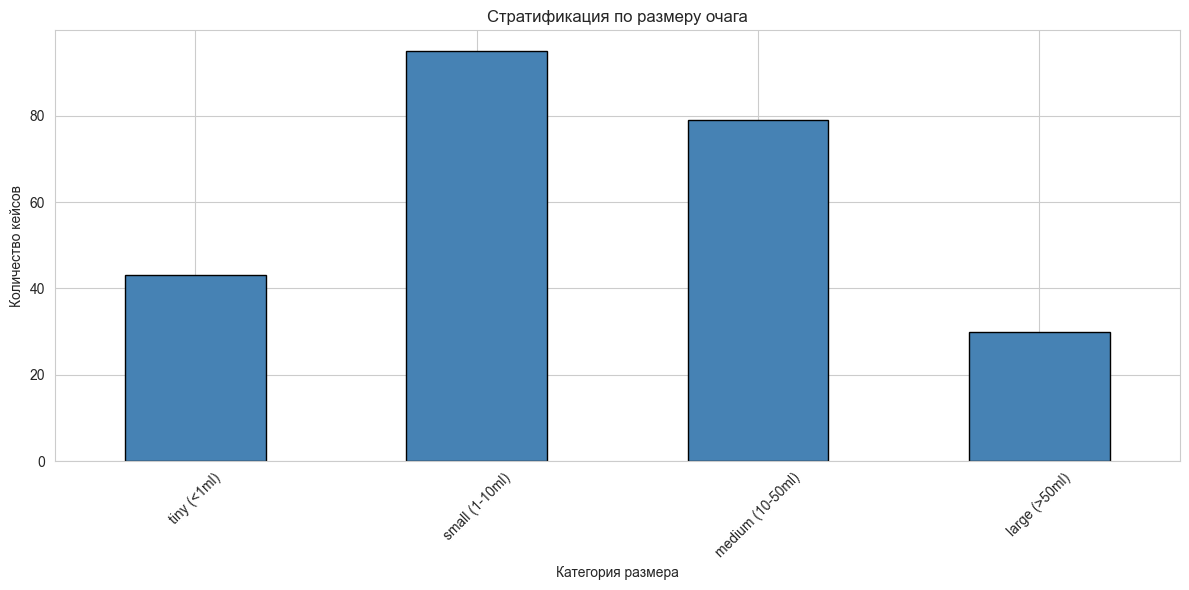

In [8]:
# Категории по размеру (как в плане)
df["size_category"] = pd.cut(
    df["volume_ml"],
    bins=[0, 1, 10, 50, 1000],
    labels=["tiny (<1ml)", "small (1-10ml)", "medium (10-50ml)", "large (>50ml)"]
)

print("Распределение по категориям размера:")
print(df["size_category"].value_counts().sort_index())

# Визуализация
df["size_category"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Категория размера")
plt.ylabel("Количество кейсов")
plt.title("Стратификация по размеру очага")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Spacing и размеры volumes

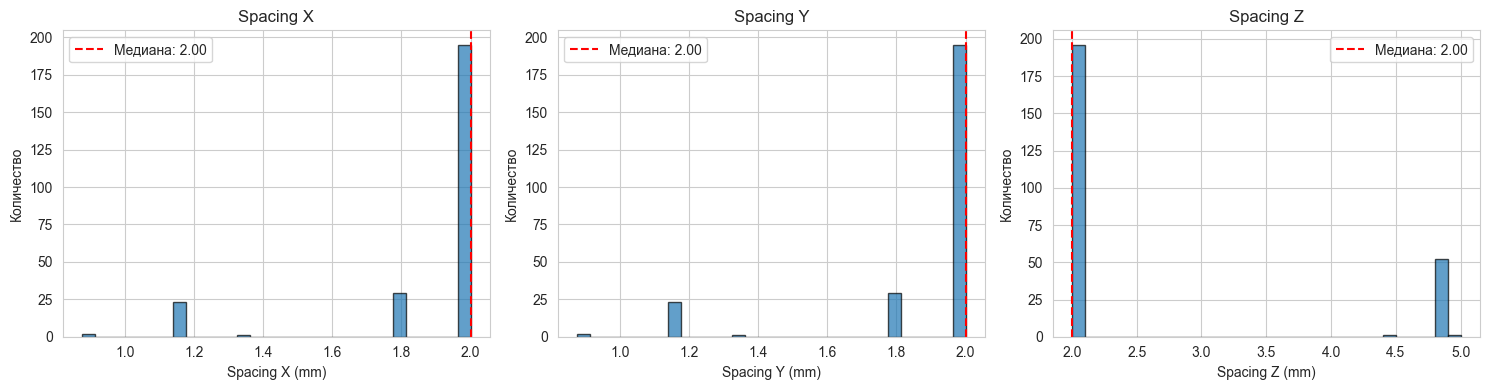

Spacing статистика:
        spacing_x   spacing_y   spacing_z
count  250.000000  250.000000  250.000000
mean     1.886135    1.886135    2.604000
std      0.266519    0.266519    1.153371
min      0.875000    0.875000    2.000000
25%      2.000000    2.000000    2.000000
50%      2.000000    2.000000    2.000000
75%      2.000000    2.000000    2.000000
max      2.000000    2.000000    5.000000


In [9]:
# Spacing распределение
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, axis in enumerate(["x", "y", "z"]):
    col = f"spacing_{axis}"
    axes[i].hist(df[col], bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_xlabel(f"Spacing {axis.upper()} (mm)")
    axes[i].set_ylabel("Количество")
    axes[i].set_title(f"Spacing {axis.upper()}")
    axes[i].axvline(df[col].median(), color="red", linestyle="--", label=f"Медиана: {df[col].median():.2f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

print("Spacing статистика:")
print(df[["spacing_x", "spacing_y", "spacing_z"]].describe())

In [10]:
# Размеры volumes
print("Размеры volumes (shape):")
print(df[["shape_x", "shape_y", "shape_z"]].describe())

Размеры volumes (shape):
         shape_x    shape_y     shape_z
count  250.00000  250.00000  250.000000
mean   122.87600  122.87600   62.736000
std     26.19445   26.19445   18.613871
min    112.00000  112.00000   25.000000
25%    112.00000  112.00000   72.000000
50%    112.00000  112.00000   72.000000
75%    112.00000  112.00000   73.000000
max    256.00000  256.00000   76.000000


## 7. Проблемные кейсы

### 7.1 Мелкие очаги (< 1 ml)

In [11]:
tiny_lesions = df[df["volume_ml"] < 1.0]
print(f"Кейсов с очагами < 1 ml: {len(tiny_lesions)} ({len(tiny_lesions)/len(df)*100:.1f}%)")
print("\nПримеры:")
print(tiny_lesions[["subject_id", "volume_ml"]].head(10))

Кейсов с очагами < 1 ml: 46 (18.4%)

Примеры:
            subject_id  volume_ml
1   sub-strokecase0002      0.944
5   sub-strokecase0006      0.040
7   sub-strokecase0008      0.752
11  sub-strokecase0012      0.448
15  sub-strokecase0016      0.208
29  sub-strokecase0030      0.512
31  sub-strokecase0032      0.536
34  sub-strokecase0035      0.144
36  sub-strokecase0037      0.488
44  sub-strokecase0045      0.768


### 7.2 Posterior fossa (проверка по z-координате центра масс)

In [12]:
# Для детекции posterior fossa нужно смотреть центр масс очага
# Это требует дополнительного анализа, пока пропускаем
# TODO: реализовать в следующей итерации
print("TODO: Детекция posterior fossa — требует анализа центра масс очага")

TODO: Детекция posterior fossa — требует анализа центра масс очага


## 8. Визуализация примеров


sub-strokecase0001 — объём: 6.68 ml


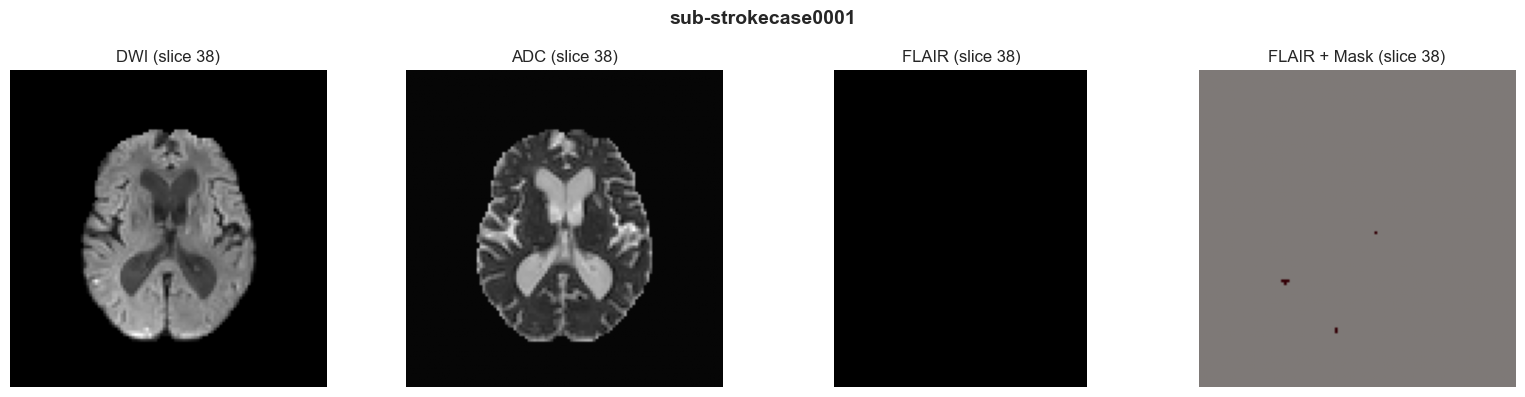


sub-strokecase0023 — объём: 482.15 ml


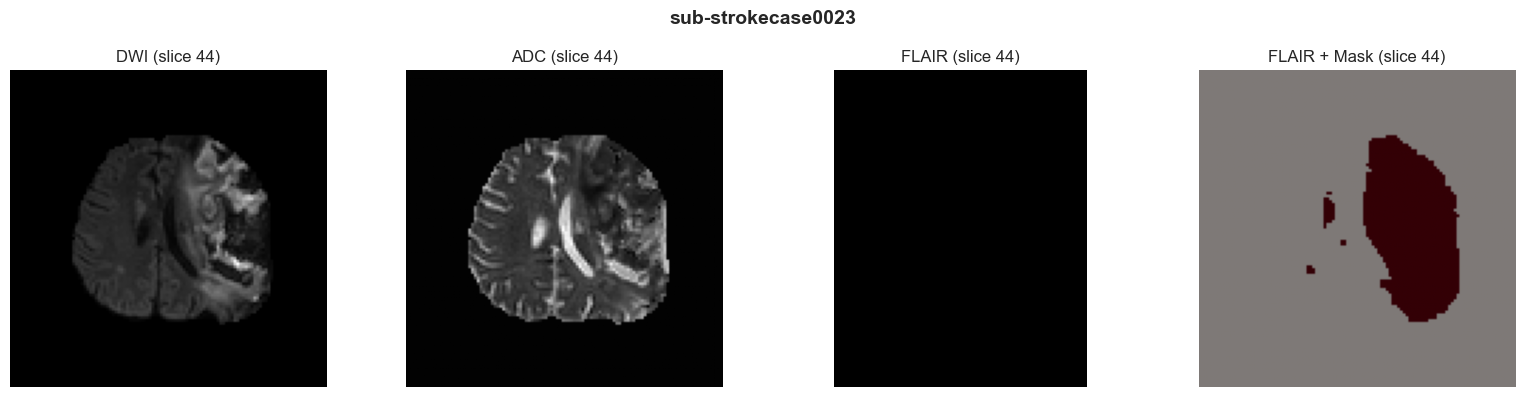


sub-strokecase0150 — объём: 0.00 ml


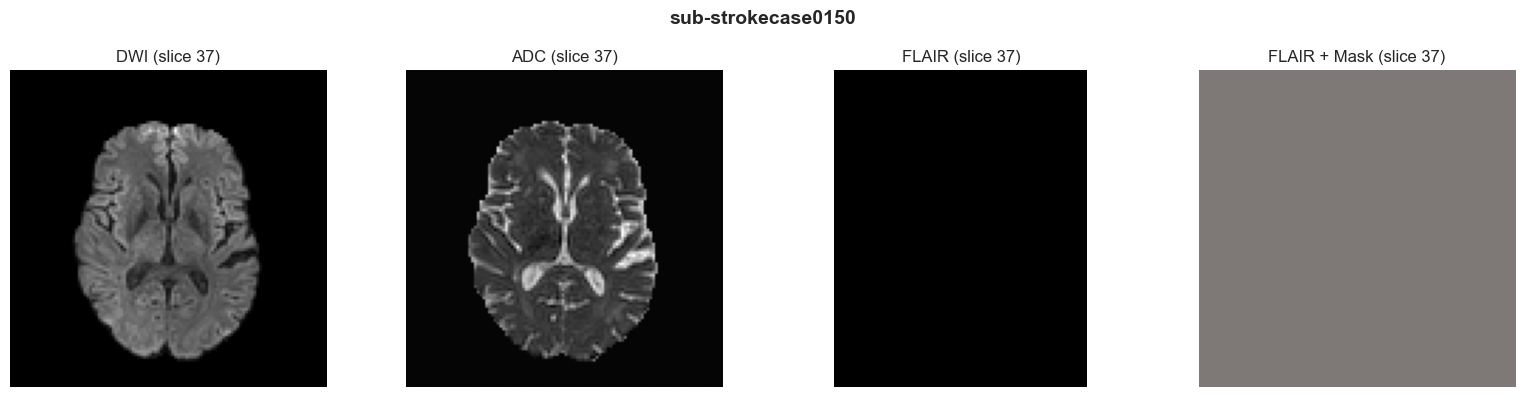

In [13]:
def visualize_case(subject_id: str, slice_idx: int = None):
    """Визуализация одного кейса: DWI, ADC, FLAIR, Mask."""
    paths = load_subject_paths(subject_id)
    
    dwi_img = nib.load(paths["dwi"]).get_fdata()
    adc_img = nib.load(paths["adc"]).get_fdata()
    flair_img = nib.load(paths["flair"]).get_fdata()
    mask_img = nib.load(paths["mask"]).get_fdata()
    
    # Автоподбор среза с очагом
    if slice_idx is None:
        lesion_slices = np.where(mask_img.sum(axis=(0, 1)) > 0)[0]
        if len(lesion_slices) > 0:
            slice_idx = lesion_slices[len(lesion_slices) // 2]  # средний срез с очагом
        else:
            slice_idx = mask_img.shape[2] // 2
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(dwi_img[:, :, slice_idx].T, cmap="gray", origin="lower")
    axes[0].set_title(f"DWI (slice {slice_idx})")
    axes[0].axis("off")
    
    axes[1].imshow(adc_img[:, :, slice_idx].T, cmap="gray", origin="lower")
    axes[1].set_title(f"ADC (slice {slice_idx})")
    axes[1].axis("off")
    
    axes[2].imshow(flair_img[:, :, slice_idx].T, cmap="gray", origin="lower")
    axes[2].set_title(f"FLAIR (slice {slice_idx})")
    axes[2].axis("off")
    
    axes[3].imshow(flair_img[:, :, slice_idx].T, cmap="gray", origin="lower")
    axes[3].imshow(mask_img[:, :, slice_idx].T, cmap="Reds", alpha=0.5, origin="lower")
    axes[3].set_title(f"FLAIR + Mask (slice {slice_idx})")
    axes[3].axis("off")
    
    plt.suptitle(f"{subject_id}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Визуализация нескольких примеров
example_subjects = [
    subjects[0],  # первый
    df.loc[df["volume_ml"].idxmax(), "subject_id"],  # самый большой очаг
    df.loc[df["volume_ml"].idxmin(), "subject_id"],  # самый маленький очаг
]

for subj in example_subjects:
    volume = df.loc[df["subject_id"] == subj, "volume_ml"].values[0]
    print(f"\n{subj} — объём: {volume:.2f} ml")
    visualize_case(subj)

## 9. Сохранить метаданные

In [14]:
# Сохранить для дальнейшего использования
output_path = project_root / "data" / "processed" / "isles22_metadata.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Метаданные сохранены: {output_path}")

Метаданные сохранены: c:\Users\mfayz\MRI Stroke Assistance\data\processed\isles22_metadata.csv


## 10. Выводы

**TODO:** Заполнить после выполнения всех ячеек:

1. Сколько кейсов всего: ?
2. Медиана объёма: ?
3. Сколько мелких (< 1 ml): ?
4. Spacing типичный: ?
5. Проблемы (артефакты, missing data): ?

---

**Next steps:**
- Определить 5-fold CV splits со стратификацией
- Реализовать Dataset class
- Preprocessing pipeline